In [1]:
# ## 1. Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.spatial.distance import cdist
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)


✓ Data Generated: 100 Rumah, 3 TPS


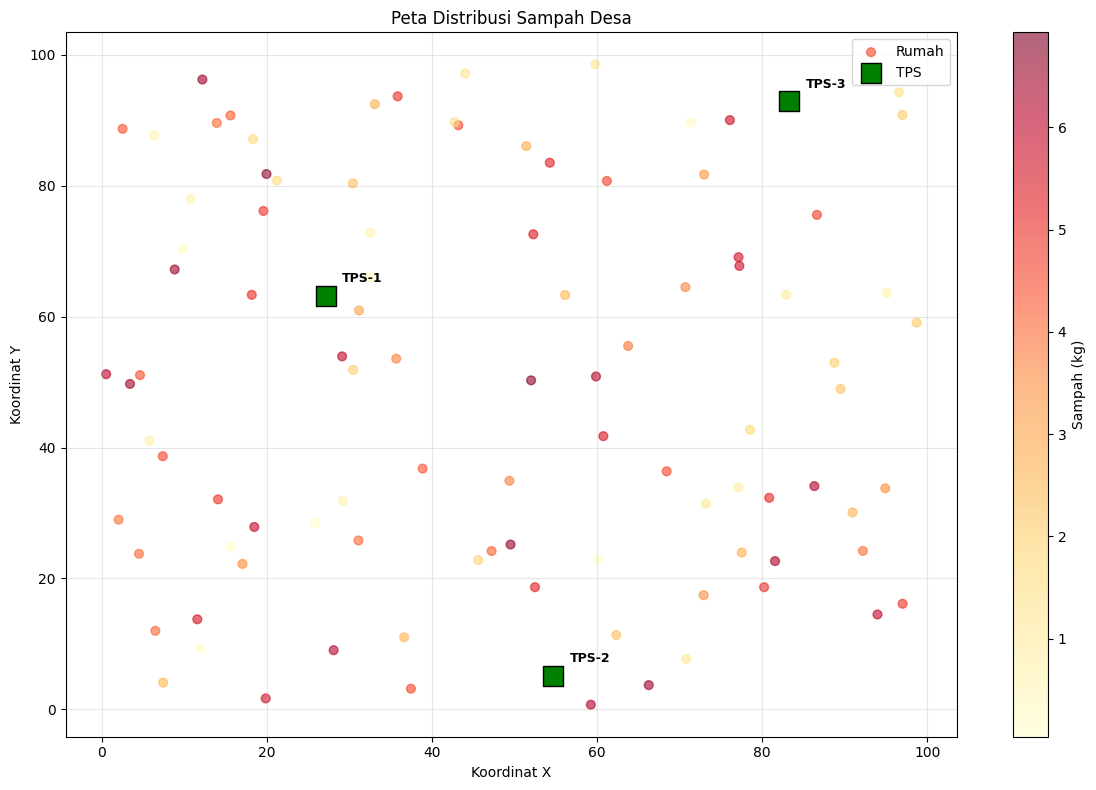

✓ Armada: 7 Gerobak, 2 Truk
🔄 Running Simulation...


ValueError: Unsupported dtype object

In [3]:
# ## 1. Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.spatial.distance import cdist
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# %% [markdown]
# ## 2. Parameter Sistem (Konfigurasi Soal)
PARAMS = {
    # Demografi & Jarak
    'num_houses': 100,
    'waste_range': (0, 7),        # kg per rumah
    'dist_range': (1, 5),         # satuan jarak
    
    # Armada & Kapasitas
    'num_carts': (5, 7),          # jumlah gerobak
    'num_trucks': (2, 4),         # jumlah truk
    'cart_cap': 15,               # kg
    'truck_cap': 200,             # kg
    'tps_cap': (400, 500),        # kg per TPS
    'num_tps': 3,
    
    # Waktu Operasi (dalam menit dari 00:00)
    'cart_hours': (6*60, 15*60),  # 06:00 - 15:00
    'truck_hours': (8*60, 17*60), # 08:00 - 17:00
    
    # Konstanta Waktu (Loading & Travel)
    'cart_load_per_kg': 2,        # menit/kg
    'cart_travel_per_unit': 3,    # menit/satuan jarak
    'truck_load_per_10kg': 2,     # menit/10kg
    'truck_travel_per_5unit': 3,  # menit/5 satuan jarak
}

# %% [markdown]
# ## 3. Generasi Data Desa
def generate_village_data(params):
    """Generate data rumah, TPS, dan matriks jarak sesuai spesifikasi soal."""
    
    # 1. Generate 100 Rumah
    houses = pd.DataFrame({
        'id': range(1, params['num_houses']+1),
        'x': np.random.uniform(0, 100, params['num_houses']),
        'y': np.random.uniform(0, 100, params['num_houses']),
        'waste': np.random.uniform(*params['waste_range'], params['num_houses']).round(2)
    })
    
    # 2. Matriks Jarak (Euclidean dinormalisasi ke skala 1-5)
    coords = houses[['x', 'y']].values
    dist_raw = cdist(coords, coords, metric='euclidean')
    # Normalisasi: scale ke range 1-5
    dist_matrix = 1 + 4 * (dist_raw - dist_raw.min()) / (dist_raw.max() - dist_raw.min())
    
    # 3. Generate 3 TPS Strategis (di area sampah padat)
    tps_indices = []
    remaining = list(range(len(houses)))
    for _ in range(params['num_tps']):
        # Pilih kandidat dengan sampah terbanyak dari sisa
        candidate = max(remaining, key=lambda i: houses.iloc[i]['waste'])
        tps_indices.append(candidate)
        # Exclude area sekitar agar TPS menyebar
        remaining = [i for i in remaining if dist_matrix[candidate, i] > 3]
    
    tps = pd.DataFrame({
        'id': [f'TPS-{i+1}' for i in range(params['num_tps'])],
        'x': [houses.iloc[i]['x'] for i in tps_indices],
        'y': [houses.iloc[i]['y'] for i in tps_indices],
        'capacity': np.random.randint(*params['tps_cap'], params['num_tps']),
        'current_load': 0.0
    })
    
    return houses, tps, dist_matrix

houses, tps, dist_matrix = generate_village_data(PARAMS)
print(f"✓ Data Generated: {len(houses)} Rumah, {len(tps)} TPS")

# %% [markdown]
# ## 4. Visualisasi Peta Penduduk
def plot_village(houses, tps, carts=None, trucks=None):
    """Plot peta desa dengan heatmap sampah dan lokasi TPS."""
    plt.figure(figsize=(12, 8))
    
    # Plot rumah (warna berdasarkan jumlah sampah)
    sc = plt.scatter(houses['x'], houses['y'], c=houses['waste'], 
                     cmap='YlOrRd', s=40, alpha=0.6, label='Rumah')
    plt.colorbar(sc, label='Sampah (kg)')
    
    # Plot TPS
    plt.scatter(tps['x'], tps['y'], c='green', s=200, marker='s', 
                edgecolors='black', label='TPS', zorder=5)
    for _, row in tps.iterrows():
        plt.text(row['x']+2, row['y']+2, row['id'], fontsize=9, fontweight='bold')
    
    plt.title('Peta Distribusi Sampah Desa')
    plt.xlabel('Koordinat X'); plt.ylabel('Koordinat Y')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_village(houses, tps)

# %% [markdown]
# ## 5. Class Kendaraan (Vehicle)
class Vehicle:
    """Base class untuk Gerobak dan Truk."""
    def __init__(self, vid, vtype, cap, start_t, end_t, is_truck=False):
        self.id = vid
        self.vtype = vtype  # 'cart' or 'truck'
        self.capacity = cap
        self.start_t = start_t
        self.end_t = end_t
        self.is_truck = is_truck
        
        self.cur_load = 0.0
        self.cur_pos = None
        self.cur_time = start_t
        self.total_dist = 0.0
        self.logs = []  # [(time, action, amount)]
    
    def calc_travel_time(self, dist_units):
        """Hitung waktu tempuh berdasarkan jenis kendaraan."""
        if self.is_truck:
            # Truk: 3 menit per 5 satuan jarak
            return (dist_units / 5.0) * PARAMS['truck_travel_per_5unit']
        else:
            # Gerobak: 3 menit per 1 satuan jarak
            return dist_units * PARAMS['cart_travel_per_unit']
    
    def calc_load_time(self, amount_kg):
        """Hitung waktu loading berdasarkan jenis kendaraan."""
        if self.is_truck:
            # Truk: 2 menit per 10 kg
            return (amount_kg / 10.0) * PARAMS['truck_load_per_10kg']
        else:
            # Gerobak: 2 menit per 1 kg
            return amount_kg * PARAMS['cart_load_per_kg']
    
    def move_to(self, target_pos):
        """Pindah posisi dan update waktu + jarak."""
        # Hitung jarak euclidean, lalu konversi ke 'satuan jarak' (1-5)
        raw_dist = np.linalg.norm(np.array(self.cur_pos) - np.array(target_pos))
        # Scaling factor: asumsi 20 unit koordinat = 1 satuan jarak soal
        units = max(1, min(5, raw_dist / 20.0))
        
        travel_time = self.calc_travel_time(units)
        
        if self.cur_time + travel_time <= self.end_t:
            self.cur_time += travel_time
            self.total_dist += units
            self.cur_pos = target_pos
            return True
        return False
    
    def load(self, amount, source_name):
        """Ambil sampah (dari rumah/TPS/Transfer)."""
        if self.cur_load + amount <= self.capacity:
            load_time = self.calc_load_time(amount)
            if self.cur_time + load_time <= self.end_t:
                self.cur_time += load_time
                self.cur_load += amount
                self.logs.append((self.cur_time, f"Ambil {source_name}", amount))
                return True
        return False
    
    def unload(self, target_name, target_cap_avail):
        """Buang sampah ke TPS (hanya untuk Gerobak/Truk ke TPS)."""
        if self.cur_load > 0:
            amount = min(self.cur_load, target_cap_avail)
            if amount > 0:
                load_time = self.calc_load_time(amount) # Reuse logic
                if self.cur_time + load_time <= self.end_t:
                    self.cur_time += load_time
                    self.cur_load -= amount
                    self.logs.append((self.cur_time, f"Buang ke {target_name}", amount))
                    return amount
        return 0

    def transfer_to(self, other_vehicle):
        """Gerobak transfer sampah ke Truk."""
        if self.is_truck or not other_vehicle.is_truck: return 0
        amount = min(self.cur_load, other_vehicle.capacity - other_vehicle.cur_load)
        if amount > 0:
            # Waktu transfer pakai aturan gerobak (2 menit/kg)
            transfer_time = amount * PARAMS['cart_load_per_kg']
            if self.cur_time + transfer_time <= self.end_t and other_vehicle.cur_time + transfer_time <= other_vehicle.end_t:
                self.cur_time += transfer_time
                other_vehicle.cur_time += transfer_time
                self.cur_load -= amount
                other_vehicle.cur_load += amount
                self.logs.append((self.cur_time, f"Transfer ke {other_vehicle.id}", amount))
                other_vehicle.logs.append((other_vehicle.cur_time, f"Terima dari {self.id}", amount))
                return amount
        return 0

# %% [markdown]
# ## 6. Inisialisasi Armada
def init_fleet(tps):
    carts = {}
    for i in range(random.randint(*PARAMS['num_carts'])):
        start_pos = tps.iloc[i % 3][['x', 'y']].values
        c = Vehicle(f'G{i+1}', 'cart', PARAMS['cart_cap'], *PARAMS['cart_hours'])
        c.cur_pos = start_pos
        carts[c.id] = c
        
    trucks = {}
    for i in range(random.randint(*PARAMS['num_trucks'])):
        start_pos = tps.iloc[i % 3][['x', 'y']].values
        t = Vehicle(f'T{i+1}', 'truck', PARAMS['truck_cap'], *PARAMS['truck_hours'], is_truck=True)
        t.cur_pos = start_pos
        trucks[t.id] = t
    return carts, trucks

carts, trucks = init_fleet(tps)
print(f"✓ Armada: {len(carts)} Gerobak, {len(trucks)} Truk")

# ## 7. Algoritma Routing & Simulasi (FIXED)
# %% [markdown]
# ## 7. Algoritma Routing & Simulasi (FIXED v2)
def run_simulation(houses, tps, carts, trucks, dist_matrix):
    remaining_waste = houses['waste'].copy()
    EPS = 0.01  # Toleransi floating point
    
    # === FASE 1: GERObak Mengambil dari Rumah ===
    for cid, cart in carts.items():
        unvisited = set(houses.index)
        max_iter = 500
        iter_count = 0
        
        while cart.cur_time < cart.end_t and unvisited and iter_count < max_iter:
            iter_count += 1
            
            # Cari rumah terdekat
            nearest, min_d = None, float('inf')
            for idx in unvisited:
                if remaining_waste[idx] > EPS and cart.cur_pos is not None:
                    d = np.linalg.norm(np.array(cart.cur_pos) - houses.iloc[idx][['x','y']].values)
                    if d < min_d:
                        min_d, nearest = d, idx
            
            if nearest is None:
                break
            
            target = houses.iloc[nearest][['x','y']].values
            
            if not cart.move_to(target):
                break
            
            # Ambil sampah
            take = min(remaining_waste[nearest], cart.capacity - cart.cur_load)
            if take > EPS and cart.load(take, f"Rumah-{nearest+1}"):
                remaining_waste[nearest] -= take
                if remaining_waste[nearest] <= EPS:
                    unvisited.remove(nearest)
            
            # Transfer ke truk jika muatan >70%
            if cart.cur_load > PARAMS['cart_cap'] * 0.7 and cart.cur_pos is not None:
                for truck in trucks.values():
                    if (truck.cur_time < truck.end_t and truck.cur_load < truck.capacity 
                        and truck.cur_pos is not None):
                        dist_to_truck = np.linalg.norm(np.array(cart.cur_pos) - np.array(truck.cur_pos))
                        if dist_to_truck < 30:
                            cart.transfer_to(truck)
                            break
            
            # Jika gerobak penuh, buang ke TPS
            if cart.cur_load >= PARAMS['cart_cap'] - EPS and cart.cur_pos is not None:
                tps_coords = tps[['x','y']].values
                if len(tps_coords) > 0:
                    tps_dists = cdist([cart.cur_pos], tps_coords)[0]
                    nearest_tps_idx = np.argmin(tps_dists)
                    target_tps = tps.iloc[nearest_tps_idx]
                    
                    if cart.move_to(target_tps[['x','y']].values):
                        cap_avail = target_tps['capacity'] - target_tps['current_load']
                        unloaded = cart.unload(target_tps['id'], cap_avail)
                        if unloaded > EPS:
                            idx = tps[tps['id']==target_tps['id']].index[0]
                            tps.loc[idx, 'current_load'] += unloaded
                else:
                    break
        
        # Cleanup akhir shift gerobak
        if cart.cur_load > EPS and cart.cur_time < cart.end_t and cart.cur_pos is not None:
            tps_coords = tps[['x','y']].values
            if len(tps_coords) > 0:
                tps_dists = cdist([cart.cur_pos], tps_coords)[0]
                target_tps = tps.iloc[np.argmin(tps_dists)]
                if cart.move_to(target_tps[['x','y']].values):
                    cap_avail = target_tps['capacity'] - target_tps['current_load']
                    cart.unload(target_tps['id'], cap_avail)

    # === FASE 2: Truk Mengambil dari TPS ===
    for tid, truck in trucks.items():
        max_iter = 200
        iter_count = 0
        
        while truck.cur_time < truck.end_t and iter_count < max_iter:
            iter_count += 1
            
            # Filter TPS yang ada sampahnya DAN koordinat valid
            active_tps = tps[(tps['current_load'] > EPS) & (tps['x'].notna()) & (tps['y'].notna())]
            if active_tps.empty or truck.cur_pos is None:
                break
            
            # Validasi sebelum cdist
            truck_pos = np.array(truck.cur_pos).reshape(1, -1)
            tps_coords = active_tps[['x','y']].values
            
            if tps_coords.shape[1] != 2 or len(truck_pos[0]) != 2:
                break  # Shape tidak kompatibel, keluar aman
            
            tps_dists = cdist(truck_pos, tps_coords)[0]
            target_tps = active_tps.iloc[np.argmin(tps_dists)]
            
            if not truck.move_to(target_tps[['x','y']].values):
                break
            
            take = min(target_tps['current_load'], truck.capacity - truck.cur_load)
            if take > EPS and truck.load(take, target_tps['id']):
                tps.loc[tps['id']==target_tps['id'], 'current_load'] -= take
            
            # Jika truk penuh, kembalikan ke TPS utama
            if truck.cur_load >= PARAMS['truck_cap'] - EPS:
                main_tps = tps.iloc[0]
                if truck.move_to(main_tps[['x','y']].values):
                    truck.unload(main_tps['id'], main_tps['capacity'])
                else:
                    break
        
        # Cleanup akhir shift truk
        if truck.cur_load > EPS and truck.cur_time < truck.end_t and truck.cur_pos is not None:
            main_tps = tps.iloc[0]
            if truck.move_to(main_tps[['x','y']].values):
                truck.unload(main_tps['id'], main_tps['capacity'])

    return remaining_waste

# Jalankan simulasi
print("🔄 Running Simulation...")
final_remaining = run_simulation(houses, tps, carts, trucks, dist_matrix)
print("✅ Simulation Finished.")

# %% [markdown]
# ## 8. Laporan Hasil (Wajib 100 Poin)
def generate_report(carts, trucks, tps, houses, remaining):
    print("\n" + "="*60)
    print("📋 LAPORAN PENGELOLAAN SAMPAH DESA")
    print("="*60)
    
    # 1. Jarak Truk
    print("\n🚛 1. JARAK TEMPUH TRUK (Satuan Jarak)")
    total_truck_dist = 0
    for tid, t in trucks.items():
        print(f"   {tid}: {t.total_dist:.2f}")
        total_truck_dist += t.total_dist
    print(f"   >> TOTAL TRUK: {total_truck_dist:.2f}")
    
    # 2. Jarak Gerobak
    print("\n🛒 2. JARAK TEMPUH GERObak (Satuan Jarak)")
    total_cart_dist = 0
    for cid, c in carts.items():
        print(f"   {cid}: {c.total_dist:.2f}")
        total_cart_dist += c.total_dist
    print(f"   >> TOTAL GERObak: {total_cart_dist:.2f}")
    
    # 3. Report Pergerakan Sampah (Transparansi)
    print("\n📊 3. REPORT PERGERAKAN SAMPAH")
    initial = houses['waste'].sum()
    in_tps = tps['current_load'].sum()
    in_houses = remaining.sum()
    in_carts = sum(c.cur_load for c in carts.values())
    in_trucks = sum(t.cur_load for t in trucks.values())
    
    print(f"   • Awal di Rumah    : {initial:.2f} kg")
    print(f"   • Akhir di TPS     : {in_tps:.2f} kg")
    print(f"   • Sisa di Rumah    : {in_houses:.2f} kg")
    print(f"   • Masih di Gerobak : {in_carts:.2f} kg")
    print(f"   • Masih di Truk    : {in_trucks:.2f} kg")
    
    # Detail Log (Sample)
    print(f"\n   [Sample Log Aktivitas]")
    for c in list(carts.values())[:2]:
        for log in c.logs[:3]:
            print(f"    {c.id} | {log[1]} @ {log[0]/60:.2f}jam ({log[2]:.1f}kg)")
    for t in list(trucks.values())[:2]:
        for log in t.logs[:3]:
            print(f"    {t.id} | {log[1]} @ {log[0]/60:.2f}jam ({log[2]:.1f}kg)")

    # 4. Waktu Operasi (50 Poin - Bagian E)
    print("\n⏱️  4. WAKTU OPERASI (Loading + Travel)")
    for c in carts.values():
        dur = c.cur_time - c.start_t
        print(f"   {c.id}: {int(dur//60)} jam {int(dur%60)} menit")
    for t in trucks.values():
        dur = t.cur_time - t.start_t
        print(f"   {t.id}: {int(dur//60)} jam {int(dur%60)} menit")

    # 5. Sisa Sampah Akhir (50 Poin - Bagian F)
    print("\n🗑️  5. SISA SAMPAH SETELAH OPERASI")
    total_unhandled = in_houses + in_carts + in_trucks
    efficiency = (1 - total_unhandled/initial) * 100
    print(f"   • Total Tidak Terangkut: {total_unhandled:.2f} kg")
    print(f"   • Efisiensi Sistem     : {efficiency:.2f}%")
    print("\n" + "="*60)

generate_report(carts, trucks, tps, houses, final_remaining)

# %% [markdown]
# ## 9. Visualisasi Akhir & Export
# Re-plot dengan info rute jika diperlukan (opsional untuk visualisasi kompleks)
plot_village(houses, tps)

# Export Ringkasan ke CSV (Opsional)
summary = pd.DataFrame({
    'Metric': ['Total Distance Trucks', 'Total Distance Carts', 'Efficiency %', 'Remaining Waste (kg)'],
    'Value': [sum(t.total_dist for t in trucks.values()), 
              sum(c.total_dist for c in carts.values()),
              (1 - (final_remaining.sum() + sum(c.cur_load for c in carts.values()) + sum(t.cur_load for t in trucks.values()))/houses['waste'].sum())*100,
              final_remaining.sum()]
})
# summary.to_csv('result_summary.csv', index=False)
print("💾 Ringkasan hasil siap di-export.")

In [ ]:
# **Checklist Requirement:**
# - [x] 100 rumah, sampah 0-7kg, jarak 1-5 satuan
# - [x] 5-7 gerobak (15kg), 2-4 truk (200kg), 3 TPS (400-500kg)
# - [x] Transfer sampah gerobak→truk saat berpapasan
# - [x] Laporan jarak per kendaraan & total (Poin 1 & 2)
# - [x] Report transparansi pergerakan sampah (Poin 3)
# - [x] Waktu operasi & loading/travel (Poin A-D)
# - [x] Hitung durasi operasi (Poin E)
# - [x] Hitung sisa sampah akhir (Poin F)
# - [x] Visualisasi peta penduduk